# 담당 1 EDA — 현재 신청(APP) 및 과거 신청(PREV) 분석

**작업자:** mw &nbsp;|&nbsp; **원천 데이터:** `application_train.csv`, `application_test.csv`, `previous_application.csv`

## 분석 목표와 해석 경계
본 프로젝트는 부실확률(상환곤란확률) 기반으로 그레이존 신청 건의 **조건 조정 가능성**을 탐색한다.
담당 1은 신청자의 재무부담(소득 대비 신용액·상환액), 외부 신용점수, 과거 신청 이력을 `SK_ID_CURR` 단위로 정리한다.

> **해석 경계 (모든 결과물에 명시)**
> - `TARGET=1`은 **상환곤란(payment difficulty)**이며 승인 거절이 아니다.
> - `previous_application.NAME_CONTRACT_STATUS`는 **과거 신청 상태**일 뿐 현재 승인 여부가 아니다.
> - 아래 결과는 **관측 상관관계**이며, 변수 변경이 상환곤란률을 낮춘다는 인과로 해석하지 않는다.
> - 실제 금융사 승인 컷오프는 데이터에 없으므로 여기서는 승인 구제율/인과효과를 주장하지 않는다.

**재현성:** 모든 경로는 저장소 루트 기준 상대경로, seed 고정, 커널 재시작 후 처음부터 끝까지 실행 가능.
그래프 라벨은 한글 폰트 미설치 환경에서도 깨지지 않도록 영문 변수명을 사용한다.

## 0. 셋업 — 저장소 루트 탐색, 임포트, 시드

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats  # noqa: F401 (환경 확인용)

# 저장소 루트를 찾아 작업 경로를 고정한다 (notebooks/ 또는 root 어디서 실행해도 동일)
def _find_root(start: Path) -> Path:
    for c in [start, *start.parents]:
        if (c / "data").is_dir() and (c / "EDA").is_dir():
            return c
    return start

REPO_ROOT = _find_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "EDA" / "src"))
import application_previous_features_mw as f  # noqa: E402

RANDOM_STATE = f.RANDOM_STATE
np.random.seed(RANDOM_STATE)

FIG_DIR = REPO_ROOT / "EDA" / "figures"
DERIVED_DIR = REPO_ROOT / "EDA" / "data" / "derived"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("REPO_ROOT =", REPO_ROOT)

REPO_ROOT = /home/claude/repo


## 1. 데이터 로드 및 구조 검증

README 실측값과 대조하여 데이터 무결성을 확인한다. 하나라도 어긋나면 `assert`로 즉시 중단된다.

In [2]:
app = pd.read_csv(REPO_ROOT / "data" / "application_train.csv")
test = pd.read_csv(REPO_ROOT / "data" / "application_test.csv")

# 구조 검증 (README 실측값)
assert app.shape == (f.EXPECTED["app_train_rows"], f.EXPECTED["app_train_cols"]), app.shape
assert len(test) == f.EXPECTED["app_test_rows"], len(test)
assert app["SK_ID_CURR"].is_unique, "train SK_ID_CURR 중복"
assert test["SK_ID_CURR"].is_unique, "test SK_ID_CURR 중복"
overlap = set(app["SK_ID_CURR"]) & set(test["SK_ID_CURR"])
assert len(overlap) == 0, f"train/test ID 중복 {len(overlap)}건"
assert int(app["TARGET"].sum()) == f.EXPECTED["target_pos"], int(app["TARGET"].sum())

n_pos = int(app["TARGET"].sum())
validation = pd.DataFrame({
    "항목": ["train 행수", "train 열수", "test 행수",
             "train/test ID 중복", "TARGET=1 건수", "상환곤란률"],
    "값": [f"{len(app):,}", app.shape[1], f"{len(test):,}",
           f"{len(overlap)}건", f"{n_pos:,}", f"{app['TARGET'].mean():.4f}"],
})
print("[표 1] 구조 검증 결과")
validation

[표 1] 구조 검증 결과


,항목,값
0,train 행수,"307,511"
1,train 열수,122
2,test 행수,"48,744"
3,train/test ID 중복,0건
4,TARGET=1 건수,"24,825"
5,상환곤란률,0.0807


### 1-b. 자료형 · 키 · 상대 날짜 방향 확인 (공통 ①③)

식별자(`SK_ID_*`)는 수치형 예측변수로 쓰지 않는다. 상대 날짜(`DAYS_*`)는 신청일 기준이며
음수가 과거임을 데이터로 검증한다.

In [3]:
# 자료형 요약
dtype_summary = app.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="n_columns")
print("[표] application_train 자료형 분포"); print(dtype_summary.to_string(index=False))

# 상대 날짜 방향 검증: DAYS_* 가 대부분 음수(과거)인지 확인
days_cols = ["DAYS_BIRTH", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE"]
dir_check = pd.DataFrame({
    "column": days_cols,
    "min": [app[c].min() for c in days_cols],
    "max": [app[c].max() for c in days_cols],
    "share_negative": [round((app[c] < 0).mean(), 4) for c in days_cols],
})
print("\n[표] 상대 날짜 방향 검증 (음수=과거)"); print(dir_check.to_string(index=False))
# previous_application 의 DAYS_DECISION 도 전부 과거여야 한다
assert (pd.read_csv(REPO_ROOT / "data" / "previous_application.csv",
                    usecols=["DAYS_DECISION"])["DAYS_DECISION"] < 0).all()
print("\nDAYS_DECISION 전부 음수(과거) 확인 완료")

[표] application_train 자료형 분포
  dtype  n_columns
float64         65
  int64         41
    str         16

[표] 상대 날짜 방향 검증 (음수=과거)
                column      min     max  share_negative
            DAYS_BIRTH -25229.0 -7489.0          1.0000
     DAYS_REGISTRATION -24672.0     0.0          0.9997
       DAYS_ID_PUBLISH  -7197.0     0.0          0.9999
DAYS_LAST_PHONE_CHANGE  -4292.0     0.0          0.8775



DAYS_DECISION 전부 음수(과거) 확인 완료


### 1-c. 변수별 결측률 스캔 (공통 ②)

train/test 결측률을 전 변수에 대해 계산하고 상위 결측 변수를 확인한다.
높은 결측(주택·외부점수 계열)은 오류가 아니라 상품 비해당·정보 미수집일 수 있어 결측 플래그 후보로 둔다.

In [4]:
miss = pd.DataFrame({
    "train_missing%": (app.isna().mean() * 100).round(2),
    "test_missing%": (test.reindex(columns=app.columns).isna().mean() * 100).round(2),
})
miss = miss.sort_values("train_missing%", ascending=False)
print("전체 변수 중 결측 있는 변수 수:", int((miss["train_missing%"] > 0).sum()))
print("\n[표] 결측률 상위 15개 변수 (train / test)")
miss.head(15)

전체 변수 중 결측 있는 변수 수: 64

[표] 결측률 상위 15개 변수 (train / test)


,train_missing%,test_missing%
COMMONAREA_AVG,69.87,68.72
COMMONAREA_MODE,69.87,68.72
COMMONAREA_MEDI,69.87,68.72
NONLIVINGAPARTMENTS_MEDI,69.43,68.41
NONLIVINGAPARTMENTS_MODE,69.43,68.41
NONLIVINGAPARTMENTS_AVG,69.43,68.41
FONDKAPREMONT_MODE,68.39,67.28
LIVINGAPARTMENTS_AVG,68.35,67.25
LIVINGAPARTMENTS_MEDI,68.35,67.25
LIVINGAPARTMENTS_MODE,68.35,67.25


## 2. 타깃 분포 — 클래스 불균형 확인

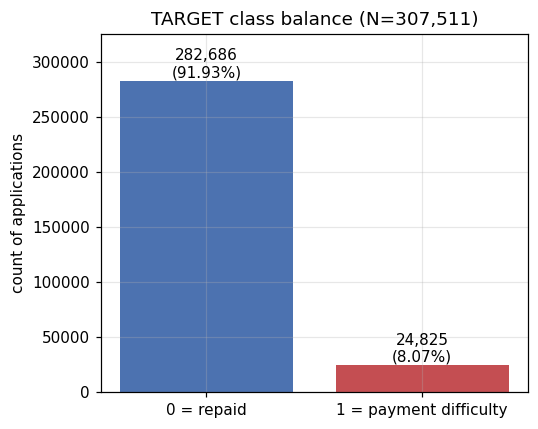

상환곤란률 8.07% — 클래스 불균형. 모델 단계에서 AUC/PR-AUC 및 임계값별 비용 평가 필요.


In [5]:
vc = app["TARGET"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["0 = repaid", "1 = payment difficulty"], vc.values,
              color=["#4C72B0", "#C44E52"])
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({v/len(app)*100:.2f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title(f"TARGET class balance (N={len(app):,})")
ax.set_ylabel("count of applications")
ax.set_ylim(0, vc.max()*1.15)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_target_balance_mw.png", bbox_inches="tight")
plt.show()
print("상환곤란률 8.07% — 클래스 불균형. 모델 단계에서 AUC/PR-AUC 및 임계값별 비용 평가 필요.")

## 3. APP_ 파생지표 생성 및 특수값 처리

`DAYS_EMPLOYED == 365243`(55,374건)은 실제 근속일이 아닌 결측 대용값이다.
플래그 생성 후 `NaN`으로 치환한다. 이어 소득 대비 부담률 등 파생지표를 만든다.

In [6]:
app = f.add_app_features(app)
test = f.add_app_features(test)

print("DAYS_EMPLOYED 특수값 플래그 건수:", int(app["APP_DAYS_EMPLOYED_ANOM"].sum()))
derived_cols = ["APP_CREDIT_INCOME_RATIO", "APP_ANNUITY_INCOME_RATIO",
                "APP_CREDIT_GOODS_RATIO", "APP_AGE_YEARS",
                "APP_EMPLOYMENT_YEARS", "APP_EXT_SOURCE_MEAN"]
print("\n[표 2] APP_ 파생지표 요약통계 (train)")
app[derived_cols].describe().round(3).T[["mean", "50%", "min", "max"]]

DAYS_EMPLOYED 특수값 플래그 건수: 55374

[표 2] APP_ 파생지표 요약통계 (train)


,mean,50%,min,max
APP_CREDIT_INCOME_RATIO,3.958,3.265,0.005,84.737
APP_ANNUITY_INCOME_RATIO,0.181,0.163,0.000,1.876
APP_CREDIT_GOODS_RATIO,1.123,1.119,0.150,6.000
APP_AGE_YEARS,43.907,43.121,20.504,69.073
APP_EMPLOYMENT_YEARS,6.527,4.512,-0.000,49.040
APP_EXT_SOURCE_MEAN,0.509,0.525,0.000,0.879


## 3-b. 인구통계·소득·주거 범주형 분포와 상환곤란률 (분석질문 ①)

성별·학력·소득유형·가족·주거 형태별 상환곤란률을 본다.
공통 규칙에 따라 표본 500건 미만 또는 전체 1% 미만 범주는 시각화에서 `OTHER`로 묶되
원본 범주는 표에 보존한다. 모든 비율에 표본수와 Wilson 95% CI 를 병기한다.

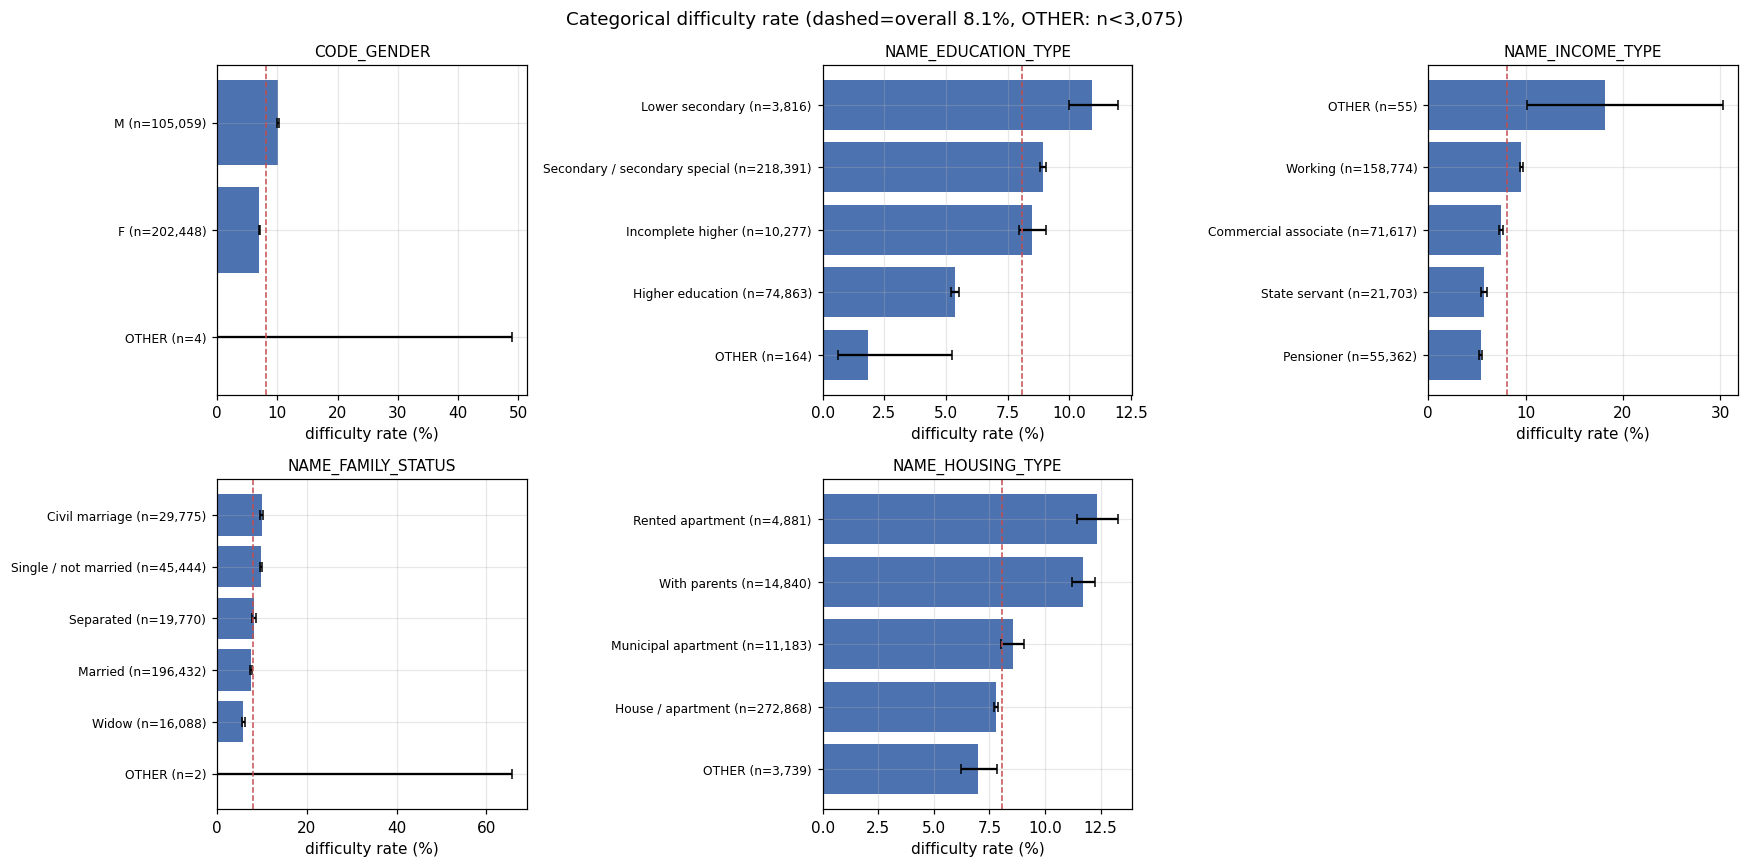

[표 3-b] 학력별 상환곤란률 — 학력↑ 곤란률↓ 단조 패턴


,NAME_EDUCATION_TYPE,n,rate
3,Lower secondary,3816,10.93
4,Secondary / secondary special,218391,8.94
2,Incomplete higher,10277,8.48
1,Higher education,74863,5.36
0,Academic degree,164,1.83


In [7]:
MIN_N = max(500, int(0.01 * len(app)))  # OTHER 묶기 기준

def categorical_rate(df, col):
    """범주별 상환곤란률 표(원본 범주 보존) + OTHER 묶은 표시용 표를 반환."""
    full = f.rate_table_with_ci(df.rename(columns={col: "_g"}), "_g")
    full = full.rename(columns={"_g": col}).sort_values("rate", ascending=False)
    small = full["n"] < MIN_N
    disp = full.copy()
    disp[col] = disp[col].where(~small, "OTHER")
    disp = (disp.groupby(col, as_index=False)
                .agg(n=("n", "sum"), n_pos=("n_pos", "sum")))
    disp["rate"] = disp["n_pos"] / disp["n"]
    ci = disp.apply(lambda r: f.wilson_ci(int(r["n_pos"]), int(r["n"])), axis=1)
    disp["ci_low"] = [c[0] for c in ci]; disp["ci_high"] = [c[1] for c in ci]
    return full, disp.sort_values("rate", ascending=False)

cat_cols = ["CODE_GENDER", "NAME_EDUCATION_TYPE", "NAME_INCOME_TYPE",
            "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
base_rate = app["TARGET"].mean() * 100
for ax, col in zip(axes.ravel(), cat_cols):
    _, disp = categorical_rate(app, col)
    yerr = np.vstack([disp["rate"]-disp["ci_low"], disp["ci_high"]-disp["rate"]]) * 100
    ax.barh(range(len(disp)), disp["rate"]*100, xerr=yerr, color="#4C72B0", capsize=3)
    ax.set_yticks(range(len(disp)))
    ax.set_yticklabels([f"{c} (n={n:,})" for c, n in zip(disp[col], disp["n"])], fontsize=8)
    ax.axvline(base_rate, color="#C44E52", ls="--", lw=1)
    ax.set_title(col, fontsize=10); ax.invert_yaxis()
    ax.set_xlabel("difficulty rate (%)")
axes.ravel()[-1].axis("off")
fig.suptitle(f"Categorical difficulty rate (dashed=overall {base_rate:.1f}%, OTHER: n<{MIN_N:,})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig08_categorical_rate_mw.png", bbox_inches="tight")
plt.show()

# 학력은 순서형이라 원본 범주 표로 단조성 확인
edu_full, _ = categorical_rate(app, "NAME_EDUCATION_TYPE")
edu_full["rate"] = (edu_full["rate"]*100).round(2)
print("[표 3-b] 학력별 상환곤란률 — 학력↑ 곤란률↓ 단조 패턴")
edu_full[["NAME_EDUCATION_TYPE", "n", "rate"]]

## 4. 재무부담과 상환곤란률 (분석질문 ②)

상환부담률(`APP_ANNUITY_INCOME_RATIO`)과 소득대비신용액(`APP_CREDIT_INCOME_RATIO`)을
구간화하여 관측 상환곤란률과 Wilson 95% 신뢰구간을 함께 본다.
구간 분모(표본수)를 막대로 병기한다.

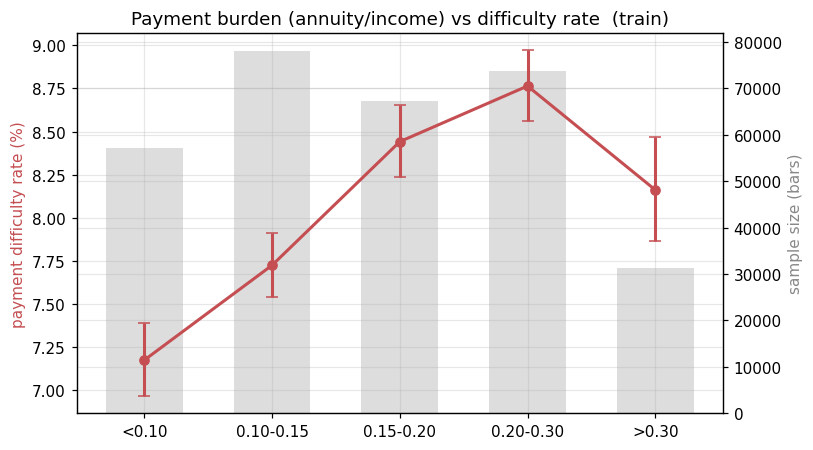

[표 3] 상환부담률 구간별 상환곤란률(%)


,_bin,n,rate,ci_low,ci_high
0,<0.10,57210,7.18,6.97,7.39
1,0.10-0.15,78018,7.73,7.54,7.91
2,0.15-0.20,67213,8.44,8.23,8.65
3,0.20-0.30,73742,8.76,8.56,8.97
4,>0.30,31316,8.16,7.86,8.47


In [8]:
def plot_rate_by_bins(df, col, bins, labels, fname, title):
    tmp = df[[col, "TARGET"]].copy()
    tmp["_bin"] = pd.cut(tmp[col], bins=bins, labels=labels)
    t = f.rate_table_with_ci(tmp, "_bin")
    order = {l: i for i, l in enumerate(labels)}
    t = t.sort_values("_bin", key=lambda s: s.map(order)).reset_index(drop=True)

    fig, ax1 = plt.subplots(figsize=(7.5, 4.2))
    ax2 = ax1.twinx()
    ax2.bar(range(len(t)), t["n"], color="#DDDDDD", width=0.6, label="sample size")
    yerr = np.vstack([t["rate"]-t["ci_low"], t["ci_high"]-t["rate"]]) * 100
    ax1.errorbar(range(len(t)), t["rate"]*100, yerr=yerr, marker="o",
                 color="#C44E52", capsize=4, lw=2, label="difficulty rate")
    ax1.set_xticks(range(len(t)))
    ax1.set_xticklabels(t["_bin"].astype(str), rotation=0)
    ax1.set_ylabel("payment difficulty rate (%)", color="#C44E52")
    ax2.set_ylabel("sample size (bars)", color="#888888")
    ax1.set_zorder(ax2.get_zorder()+1); ax1.patch.set_visible(False)
    ax1.set_title(title)
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, bbox_inches="tight")
    plt.show()
    disp = t[["_bin", "n", "rate", "ci_low", "ci_high"]].copy()
    for c in ["rate", "ci_low", "ci_high"]:
        disp[c] = (disp[c]*100).round(2)
    return disp

t_annuity = plot_rate_by_bins(
    app, "APP_ANNUITY_INCOME_RATIO",
    [0, .10, .15, .20, .30, 10], ["<0.10", "0.10-0.15", "0.15-0.20", "0.20-0.30", ">0.30"],
    "fig02_annuity_income_ratio_vs_default_mw.png",
    "Payment burden (annuity/income) vs difficulty rate  (train)")
print("[표 3] 상환부담률 구간별 상환곤란률(%)"); t_annuity

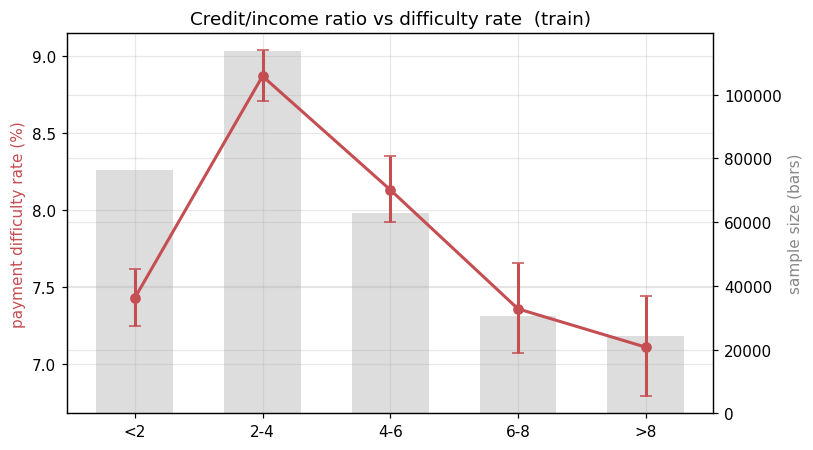

[표 4] 소득대비신용액 구간별 — 비단조 패턴 주목


,_bin,n,rate,ci_low,ci_high
0,<2,76338,7.43,7.24,7.62
1,2-4,113561,8.87,8.71,9.04
2,4-6,62887,8.13,7.92,8.35
3,6-8,30576,7.36,7.07,7.66
4,>8,24149,7.11,6.79,7.44


In [9]:
t_credit = plot_rate_by_bins(
    app, "APP_CREDIT_INCOME_RATIO",
    [0, 2, 4, 6, 8, 100], ["<2", "2-4", "4-6", "6-8", ">8"],
    "fig03_credit_income_ratio_vs_default_mw.png",
    "Credit/income ratio vs difficulty rate  (train)")
print("[표 4] 소득대비신용액 구간별 — 비단조 패턴 주목"); t_credit

## 5. 외부 신용점수와 상환곤란률 (분석질문 ③)

3개 외부점수의 평균(`APP_EXT_SOURCE_MEAN`)과 결측 여부가 상환곤란률과 어떻게 연결되는지 본다.
결측의 정보성(결측 플래그)도 함께 확인한다.

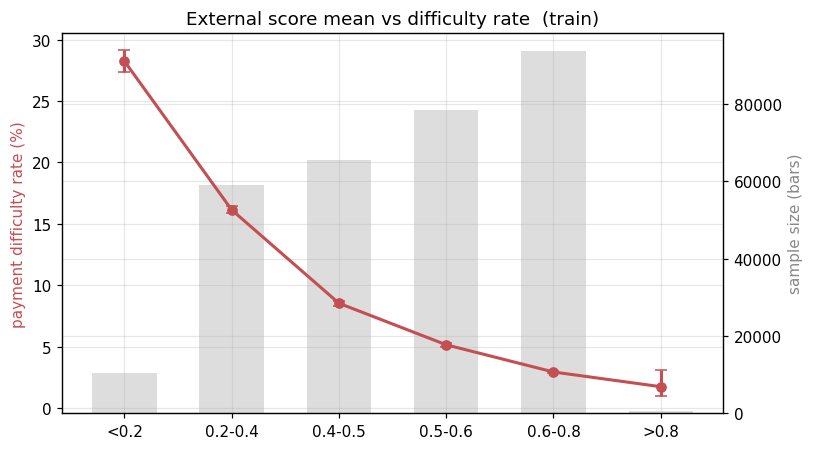

[표 5] 외부점수평균 구간별 — 압도적 단일 신호


,_bin,n,rate,ci_low,ci_high
0,<0.2,10448,28.24,27.39,29.12
1,0.2-0.4,58950,16.13,15.84,16.43
2,0.4-0.5,65387,8.52,8.31,8.74
3,0.5-0.6,78336,5.14,4.99,5.30
4,0.6-0.8,93581,2.93,2.82,3.04
5,>0.8,637,1.73,0.97,3.07


In [10]:
t_ext = plot_rate_by_bins(
    app, "APP_EXT_SOURCE_MEAN",
    [0, .2, .4, .5, .6, .8, 1.01], ["<0.2", "0.2-0.4", "0.4-0.5", "0.5-0.6", "0.6-0.8", ">0.8"],
    "fig04_ext_source_mean_vs_default_mw.png",
    "External score mean vs difficulty rate  (train)")
print("[표 5] 외부점수평균 구간별 — 압도적 단일 신호"); t_ext

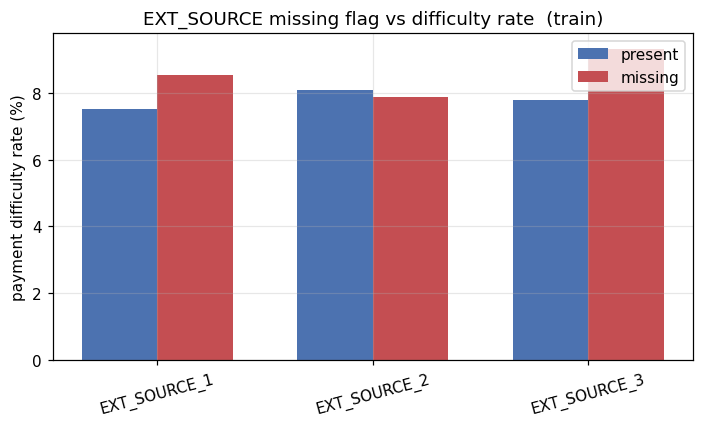

[표 6] 외부점수 결측 여부별 상환곤란률


,feature,present_rate%,missing_rate%,missing_share%
0,EXT_SOURCE_1,7.50,8.52,56.38
1,EXT_SOURCE_2,8.07,7.88,0.21
2,EXT_SOURCE_3,7.77,9.31,19.83


In [11]:
# 결측 플래그의 정보성
rows = []
for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    g = app.groupby(f"{c}_MISSING")["TARGET"].agg(n="size", rate="mean")
    rows.append({"feature": c,
                 "present_rate%": round(g.loc[0, "rate"]*100, 2) if 0 in g.index else np.nan,
                 "missing_rate%": round(g.loc[1, "rate"]*100, 2) if 1 in g.index else np.nan,
                 "missing_share%": round(app[f"{c}_MISSING"].mean()*100, 2)})
ext_missing = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(ext_missing)); w = 0.35
ax.bar(x-w/2, ext_missing["present_rate%"], w, label="present", color="#4C72B0")
ax.bar(x+w/2, ext_missing["missing_rate%"], w, label="missing", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(ext_missing["feature"], rotation=15)
ax.set_ylabel("payment difficulty rate (%)")
ax.set_title("EXT_SOURCE missing flag vs difficulty rate  (train)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig05_ext_source_missing_vs_default_mw.png", bbox_inches="tight")
plt.show()
print("[표 6] 외부점수 결측 여부별 상환곤란률"); ext_missing

## 6. 과거 신청 이력 집계 및 상환곤란률 (분석질문 ④)

`previous_application`을 청크로 읽어 `SK_ID_CURR` 단위로 집계한다.
과거 거절비율과 이력 보유 여부가 현재 상환곤란률과 어떻게 연결되는지 본다.

> `AMT_APPLICATION==0`(392,402건)에 의한 0 분모는 안전 나눗셈으로 `NaN` 처리된다.

In [12]:
prev = f.load_previous_chunked(REPO_ROOT / "data" / "previous_application.csv")
print("previous_application 로드:", prev.shape)
prev_agg = f.aggregate_previous(prev)
assert prev_agg["SK_ID_CURR"].is_unique, "PREV 집계 SK_ID_CURR 유일성 위반"
print("과거 신청 이력 보유 고객 수:", f"{prev_agg['SK_ID_CURR'].nunique():,}")

# train/test 이력 보유율(커버리지) 비교 (공통 ④⑦)
prev_ids = set(prev_agg["SK_ID_CURR"])
coverage = pd.DataFrame({
    "dataset": ["train", "test"],
    "n_customers": [len(app), len(test)],
    "has_prev%": [round(app["SK_ID_CURR"].isin(prev_ids).mean()*100, 2),
                  round(test["SK_ID_CURR"].isin(prev_ids).mean()*100, 2)],
})
print("\n[표] train/test 과거신청 이력 보유율 비교")
print(coverage.to_string(index=False))
print("\n[표 7] PREV_ 집계 피처 요약통계")
prev_agg.drop(columns="SK_ID_CURR").describe().round(3).T[["mean", "50%", "min", "max"]]

previous_application 로드: (1670214, 6)


과거 신청 이력 보유 고객 수: 338,857

[표] train/test 과거신청 이력 보유율 비교
dataset  n_customers  has_prev%
  train       307511      94.65
   test        48744      98.06

[표 7] PREV_ 집계 피처 요약통계


,mean,50%,min,max
PREV_APPLICATION_COUNT,4.929,4.000,1.0,77.000
PREV_APPROVED_RATIO,0.744,0.778,0.0,1.000
PREV_REFUSED_RATIO,0.111,0.000,0.0,1.000
PREV_CANCELED_RATIO,0.129,0.000,0.0,1.000
PREV_RECENT_DECISION_DAYS,481.489,304.000,1.0,2922.000
PREV_CREDIT_APPLICATION_RATIO,1.149,1.053,0.1,43.545


HAS_PREV 여부별 상환곤란률
               n  rate
HAS_PREV              
0          16454  5.96
1         291057  8.19


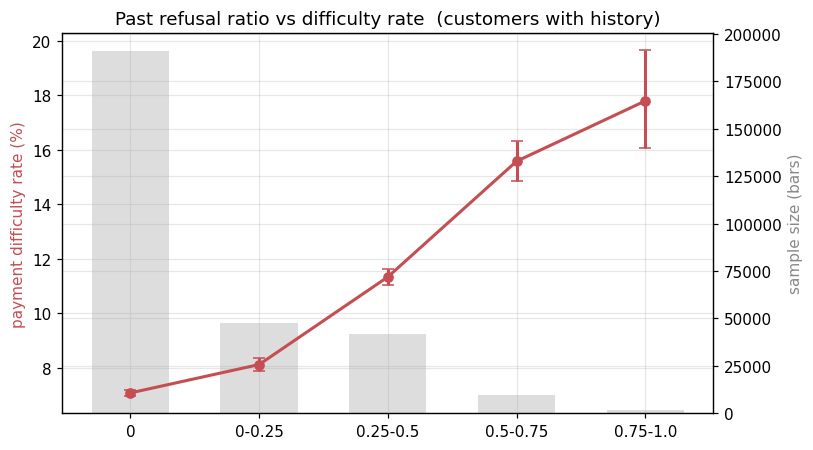

[표 8] 과거 거절비율 구간별 상환곤란률(%)


,_bin,n,rate,ci_low,ci_high
0,0,190763,7.07,6.96,7.19
1,0-0.25,47397,8.11,7.87,8.36
2,0.25-0.5,41739,11.33,11.03,11.64
3,0.5-0.75,9393,15.58,14.86,16.32
4,0.75-1.0,1765,17.79,16.08,19.64


In [13]:
# APP + PREV 결합 (도메인 1 산출물)
domain1 = f.build_domain1_features(app, prev_agg)
assert len(domain1) == len(app), "결합 후 행수 변동"
print("HAS_PREV 여부별 상환곤란률")
print(domain1.groupby("HAS_PREV")["TARGET"]
      .agg(n="size", rate=lambda s: round(s.mean()*100, 2)))

# 과거 거절비율 vs 곤란률 (이력 보유자만)
sub = domain1[domain1["HAS_PREV"] == 1]
t_ref = plot_rate_by_bins(
    sub, "PREV_REFUSED_RATIO",
    [-.01, 0, .25, .5, .75, 1.01], ["0", "0-0.25", "0.25-0.5", "0.5-0.75", "0.75-1.0"],
    "fig06_prev_refused_ratio_vs_default_mw.png",
    "Past refusal ratio vs difficulty rate  (customers with history)")
print("[표 8] 과거 거절비율 구간별 상환곤란률(%)"); t_ref

## 7. 학습·테스트 분포 비교 (분석질문 ⑤ / 공변량 이동 점검)

모델 일반화를 위해 주요 파생피처의 train/test 분포 차이를 확인한다.

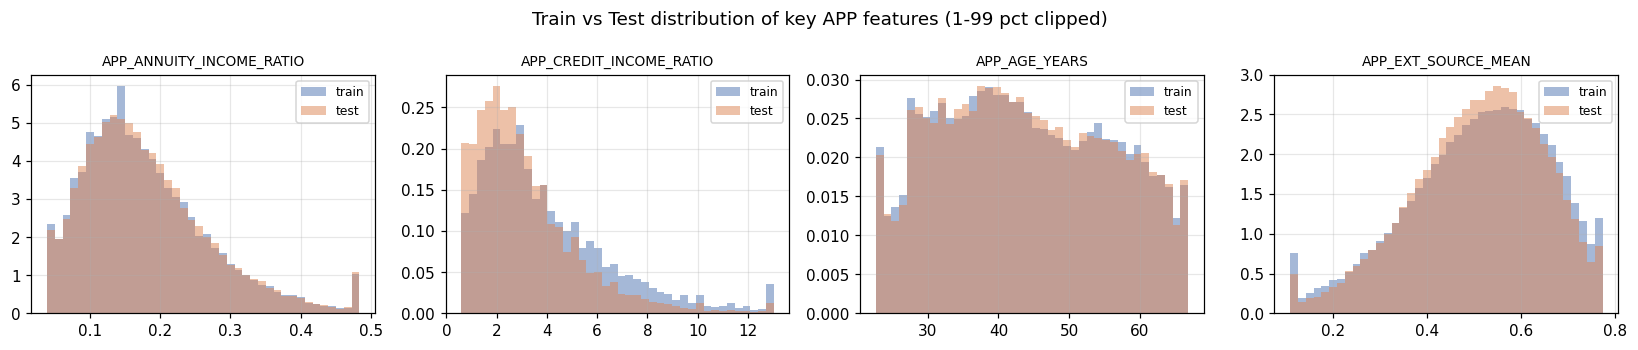

[표 9] train/test 중앙값 비교


,feature,train_median,test_median,abs_diff
0,APP_ANNUITY_INCOME_RATIO,0.1628,0.1659,0.0031
1,APP_CREDIT_INCOME_RATIO,3.2651,2.6661,0.5990
2,APP_AGE_YEARS,43.1211,43.2170,0.0959
3,APP_EXT_SOURCE_MEAN,0.5245,0.5196,0.0049


In [14]:
cmp_cols = ["APP_ANNUITY_INCOME_RATIO", "APP_CREDIT_INCOME_RATIO",
            "APP_AGE_YEARS", "APP_EXT_SOURCE_MEAN"]
cmp = pd.DataFrame({
    "feature": cmp_cols,
    "train_median": [app[c].median() for c in cmp_cols],
    "test_median": [test[c].median() for c in cmp_cols],
}).round(4)
cmp["abs_diff"] = (cmp["train_median"] - cmp["test_median"]).abs().round(4)

fig, axes = plt.subplots(1, len(cmp_cols), figsize=(15, 3.2))
for ax, c in zip(axes, cmp_cols):
    lo, hi = app[c].quantile([0.01, 0.99])
    ax.hist(app[c].clip(lo, hi), bins=40, density=True, alpha=0.5, label="train", color="#4C72B0")
    ax.hist(test[c].clip(lo, hi), bins=40, density=True, alpha=0.5, label="test", color="#DD8452")
    ax.set_title(c, fontsize=9); ax.legend(fontsize=8)
fig.suptitle("Train vs Test distribution of key APP features (1-99 pct clipped)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig07_train_test_distribution_mw.png", bbox_inches="tight")
plt.show()
print("[표 9] train/test 중앙값 비교"); cmp

## 8. 고객 단위 산출물 저장

공통 인터페이스(`SK_ID_CURR`, `HAS_PREV`, `APP_`/`PREV_` 피처)를 Parquet으로 저장한다.
파생데이터는 `EDA/data/derived/`에 두며 Git에 커밋하지 않는다(.gitignore).

In [15]:
app_prefix = [c for c in domain1.columns if c.startswith("APP_")]
prev_prefix = [c for c in domain1.columns if c.startswith("PREV_")]
keep = ["SK_ID_CURR", "TARGET", "HAS_PREV"] + app_prefix + prev_prefix
out = domain1[keep].copy()

assert out["SK_ID_CURR"].is_unique, "저장 전 SK_ID_CURR 유일성 위반"
assert not np.isinf(out.select_dtypes("number").to_numpy()).any(), "무한대 값 존재"

out_path = DERIVED_DIR / "app_prev_features_mw.parquet"
out.to_parquet(out_path, index=False)
print(f"저장 완료: {out_path.relative_to(REPO_ROOT)}")
print(f"shape = {out.shape}  |  APP_ {len(app_prefix)}개, PREV_ {len(prev_prefix)}개 피처")
out.head(3)

저장 완료: EDA/data/derived/app_prev_features_mw.parquet
shape = (307511, 17)  |  APP_ 8개, PREV_ 6개 피처


,SK_ID_CURR,TARGET,HAS_PREV,APP_DAYS_EMPLOYED_ANOM,APP_CREDIT_INCOME_RATIO,APP_ANNUITY_INCOME_RATIO,APP_CREDIT_GOODS_RATIO,APP_AGE_YEARS,APP_EMPLOYMENT_YEARS,APP_EXT_SOURCE_MEAN,APP_EXT_SOURCE_NA_COUNT,PREV_APPLICATION_COUNT,PREV_APPROVED_RATIO,PREV_REFUSED_RATIO,PREV_CANCELED_RATIO,PREV_RECENT_DECISION_DAYS,PREV_CREDIT_APPLICATION_RATIO
0,100002,1,1,0,2.007889,0.121978,1.158397,25.902806,1.744011,0.161787,0,1,1.0,0.0,0.0,606.0,1.000000
1,100003,0,1,0,4.790750,0.132217,1.145199,45.900068,3.252567,0.466757,1,3,1.0,0.0,0.0,746.0,1.111967
2,100004,0,1,0,2.000000,0.100000,1.000000,52.145106,0.616016,0.642739,1,1,1.0,0.0,0.0,815.0,0.828021


## 9. 결론 · 한계 · 모델 단계 피처 후보

### 근거 기반 결론
1. **외부 신용점수(EXT_SOURCE)가 압도적 단일 신호다.** 점수평균 하위구간(<0.2) 상환곤란률 28.2% vs
   상위구간(>0.8) 1.7%로 약 16배 차이(모두 Wilson CI 비중첩). 세 점수 중 결측 자체도 정보성이 있어
   (`EXT_SOURCE_1` 결측 8.5% vs 관측 7.5%) 결측 플래그를 피처로 유지할 가치가 있다.
2. **상환부담률(annuity/income)은 완만하지만 단조적으로 곤란률과 연결된다** (7.2% → 8.8%).
   이는 그레이존 조건조정에서 "상환액(월 부담) 축소"가 작동할 여지를 시사하는 축이다.
3. **소득대비신용액(credit/income)은 비단조**다(2~4배 구간 8.9%로 정점, 고배율 구간에서 오히려 하락).
   즉 단순히 대출금액만 줄이는 것이 항상 곤란률을 낮추지 않을 수 있다 — 프로젝트 가설②
   ("조건 조정이 통하는/통하지 않는 고객 구분")를 뒷받침하는 관측 근거다.
4. **과거 거절비율은 강한 단조 신호**다. 과거 거절 0% 고객 7.1% vs 거절 75%↑ 고객 17.8%.
   `PREV_` 도메인이 모델에 유효한 정보를 더한다.
5. **train/test 분포는 대체로 유사**하나 `APP_CREDIT_INCOME_RATIO` 중앙값이 train 3.27 vs test 2.67로
   차이가 있고, **과거신청 이력 보유율도 train 94.7% vs test 98.1%**로 달라 공변량 이동에 유의해야 한다.
   나이·외부점수·상환부담률은 거의 동일하다.
6. **범주형(분석질문①):** 학력이 높을수록 곤란률이 단조 감소(Lower secondary 10.9% → Higher 5.4% →
   Academic 1.8%)하며, 성별(M 10.1% vs F 7.0%)과 주거형태(임대 12.3%·부모동거 11.7% vs 자가 7.8%)에서도
   뚜렷한 차이가 관측된다. 표본 500건/1% 미만 범주(예: `XNA`, `Academic degree`)는 `OTHER`로 묶어 표시했다.

### 한계
- `TARGET`은 상환곤란이며 승인 거절이 아니다. 위 관계는 관측 상관이며 인과가 아니다.
- 승인 컷오프가 데이터에 없어 구제율·승인효과는 이 단계에서 주장하지 않는다.
- `NAME_CONTRACT_STATUS`는 과거 신청 상태일 뿐 현재 심사 결과가 아니다.
- 구간화는 해석용이며 모델 입력은 연속형 원값을 사용한다.

### 모델 단계 피처 후보 (담당 1 → 모델 인계)
- **강신호:** `APP_EXT_SOURCE_MEAN`, `EXT_SOURCE_1/2/3` 원값 및 `_MISSING` 플래그
- **재무부담:** `APP_ANNUITY_INCOME_RATIO`(조건조정 핵심축), `APP_CREDIT_INCOME_RATIO`, `APP_CREDIT_GOODS_RATIO`
- **인적:** `APP_AGE_YEARS`, `APP_EMPLOYMENT_YEARS`(+`APP_DAYS_EMPLOYED_ANOM`)
- **과거이력:** `PREV_REFUSED_RATIO`, `PREV_APPROVED_RATIO`, `PREV_APPLICATION_COUNT`,
  `PREV_RECENT_DECISION_DAYS`, `HAS_PREV`

### 인계 메모
- EXT_SOURCE의 강한 신호는 담당 2(외부 신용거래) 도메인과 개념적으로 연결되므로 통합 단계에서 상관/중복 점검 필요.
- 산출물: `EDA/data/derived/app_prev_features_mw.parquet` (SK_ID_CURR 유일, Application 행수 보존).